In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as  sns
df = pd.read_csv('insurance.csv.csv')
df.shape

(58592, 45)

# 🚗 Car Insurance Claim Risk Analysis
> This project analyzes vehicle insurance data to identify key risk factors influencing insurance claims.

### 📥 1. Data Loading & Understanding
- Imported essential libraries (pandas, numpy, matplotlib, seaborn).
- Loaded the dataset (58,592 rows and 45 columns) and verified that there are zero missing values.

In [2]:
df.head()

,policy_id,subscription_length,vehicle_age,customer_age,region_code,region_density,segment,model,fuel_type,max_torque,...,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,claim_status,young_claim_count,young_total_subscription,customer_age_group,vehicle_age_group
0,POL000001,5.2,1.0,54,C1,4990,A,M1,CNG,60Nm@3500rpm,...,No,No,No,Yes,0,0,815,80185.2,Seniour,New
1,POL000002,6.7,0.4,40,C2,27003,A,M1,CNG,60Nm@3500rpm,...,No,No,No,Yes,0,0,815,80185.2,Middle-Age,New
2,POL000003,8.4,0.4,40,C3,4076,A,M1,CNG,60Nm@3500rpm,...,No,No,No,Yes,0,0,815,80185.2,Middle-Age,New
3,POL000004,9.0,2.2,43,C4,21622,C1,M2,Petrol,113Nm@4400rpm,...,Yes,Yes,Yes,Yes,2,0,815,80185.2,Middle-Age,Moderate
4,POL000005,6.0,2.2,54,C5,34738,A,M3,Petrol,91Nm@4250rpm,...,No,Yes,Yes,Yes,2,0,815,80185.2,Seniour,Moderate


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 58592 entries, 0 to 58591
Data columns (total 45 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   policy_id                         58592 non-null  str    
 1   subscription_length               58592 non-null  float64
 2   vehicle_age                       58592 non-null  float64
 3   customer_age                      58592 non-null  int64  
 4   region_code                       58592 non-null  str    
 5   region_density                    58592 non-null  int64  
 6   segment                           58592 non-null  str    
 7   model                             58592 non-null  str    
 8   fuel_type                         58592 non-null  str    
 9   max_torque                        58592 non-null  str    
 10  max_power                         58592 non-null  str    
 11  engine_type                       58592 non-null  str    
 12  airbags        

In [4]:
df.isnull().sum()

policy_id                           0
subscription_length                 0
vehicle_age                         0
customer_age                        0
region_code                         0
region_density                      0
segment                             0
model                               0
fuel_type                           0
max_torque                          0
max_power                           0
engine_type                         0
airbags                             0
is_esc                              0
is_adjustable_steering              0
is_tpms                             0
is_parking_sensors                  0
is_parking_camera                   0
rear_brakes_type                    0
displacement                        0
cylinder                            0
transmission_type                   0
steering_type                       0
turning_radius                      0
length                              0
width                               0
gross_weight

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.describe()

,subscription_length,vehicle_age,customer_age,region_density,airbags,displacement,cylinder,turning_radius,length,width,gross_weight,ncap_rating,claim_status,young_claim_count,young_total_subscription
count,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.0,58592.0
mean,6.111688,1.388473,44.823935,18826.858667,3.137066,1162.355851,3.626963,4.852893,3850.476891,1672.233667,1385.276813,1.759950,0.063968,815.0,80185.2
std,4.142790,1.134413,6.935604,17660.174792,1.832641,266.304786,0.483616,0.228061,311.457119,112.089135,212.423085,1.389576,0.244698,0.0,0.0
min,0.000000,0.000000,35.000000,290.000000,1.000000,796.000000,3.000000,4.500000,3445.000000,1475.000000,1051.000000,0.000000,0.000000,815.0,80185.2
25%,2.100000,0.400000,39.000000,6112.000000,2.000000,796.000000,3.000000,4.600000,3445.000000,1515.000000,1185.000000,0.000000,0.000000,815.0,80185.2
50%,5.700000,1.200000,44.000000,8794.000000,2.000000,1197.000000,4.000000,4.800000,3845.000000,1735.000000,1335.000000,2.000000,0.000000,815.0,80185.2
75%,10.400000,2.200000,49.000000,27003.000000,6.000000,1493.000000,4.000000,5.000000,3995.000000,1755.000000,1510.000000,3.000000,0.000000,815.0,80185.2
max,14.000000,20.000000,75.000000,73430.000000,6.000000,1498.000000,4.000000,5.200000,4300.000000,1811.000000,1720.000000,5.000000,1.000000,815.0,80185.2


### 📊 2. Exploratory Data Analysis & Statistics
- Statistical summaries (describe) reviewed for numerical columns.
- Checked data distributions, central tendencies, and spread across features.

<Axes: xlabel='claim_status', ylabel='count'>

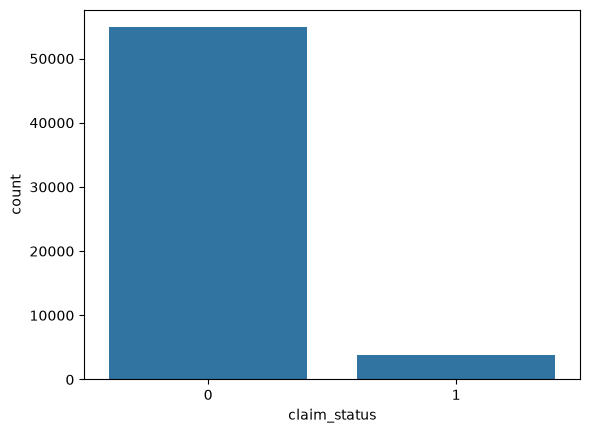

In [7]:
sns.countplot(x='claim_status',data=df)

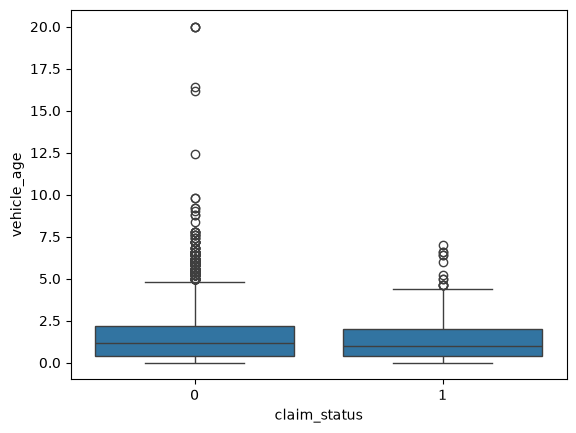

In [8]:
sns.boxplot(x='claim_status',y='vehicle_age',data=df)
plt.show()

### 📈 3. Visualizing Distributions & Relationships
- *Claim Status Distribution:* Evaluated the overall balance of claims in the dataset.
- *Vehicle Age vs. Claim Status:* Analyzed how vehicle age impacts insurance claims through box plot distributions.

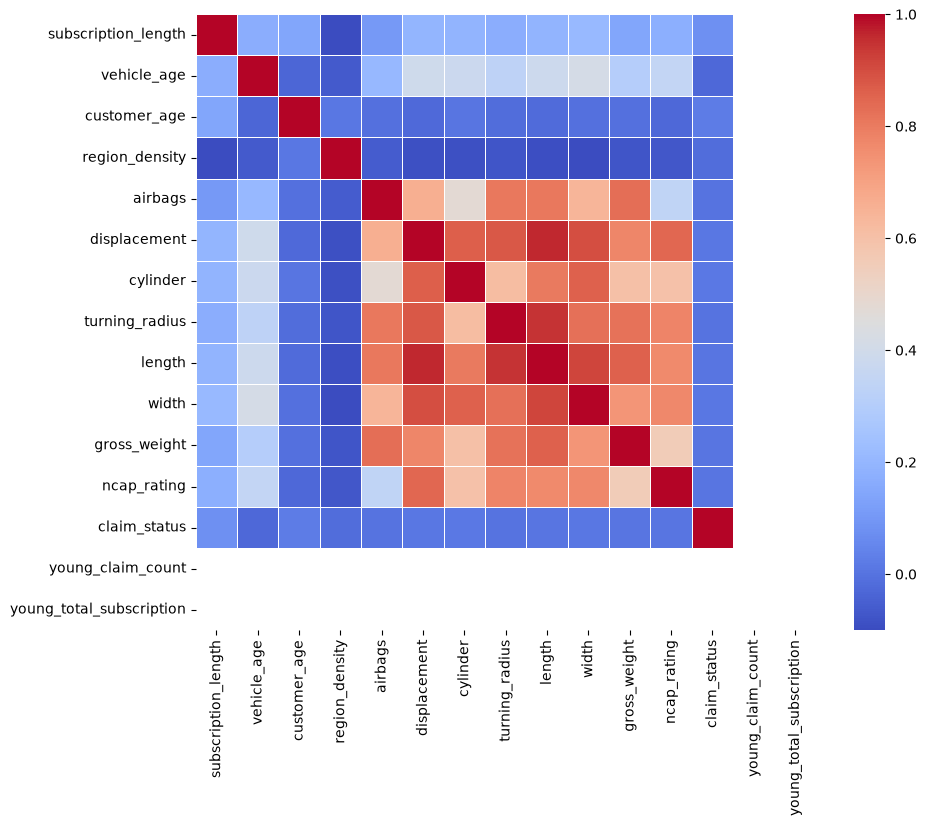

In [9]:
corr_matrix= df.select_dtypes(include=['int64','float64']).corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.show()

### 🔗 4. Correlation Analysis
- Generated a correlation heatmap to identify linear relationships between numerical features and target variables.

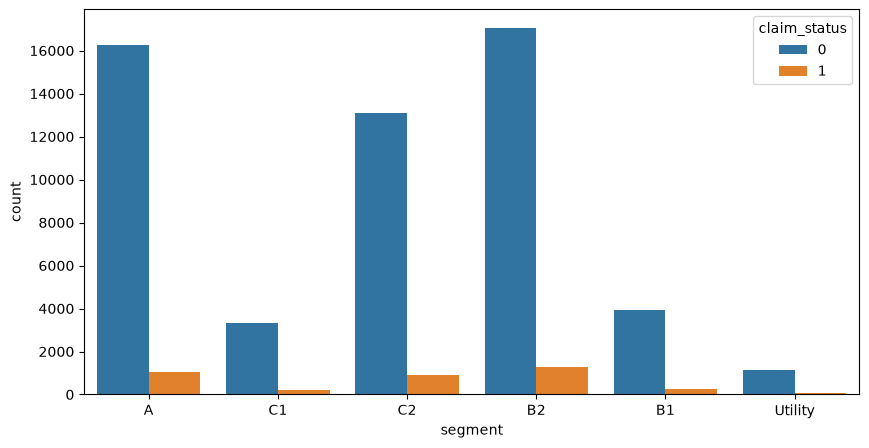

In [10]:
plt.figure(figsize=(10,5))
sns.countplot(x='segment',hue='claim_status',data=df)
plt.show()

### 🔍 5. Segment & Fuel Type Risk Analysis

In [11]:
segment_summary = df.groupby('segment')['claim_status'].agg(['count', 'sum', 'mean'])
segment_summary

,count,sum,mean
segment,,,
A,17321,1046,0.060389
B1,4173,244,0.058471
B2,18314,1256,0.068581
C1,3557,228,0.064099
C2,14018,901,0.064275
Utility,1209,73,0.060380


In [12]:
fuel_summary = df.groupby('fuel_type')['claim_status'].agg(['count', 'sum','mean'])
fuel_summary

,count,sum,mean
fuel_type,,,
CNG,20330,1235,0.060748
Diesel,17730,1150,0.064862
Petrol,20532,1363,0.066384


In [13]:
print("--- Fuel Type Ranking ---")
display(fuel_summary.sort_values(by='mean', ascending=False))

print("\n--- Segment Ranking ---")
display(segment_summary.sort_values(by='mean', ascending=False))

--- Fuel Type Ranking ---


,count,sum,mean
fuel_type,,,
Petrol,20532,1363,0.066384
Diesel,17730,1150,0.064862
CNG,20330,1235,0.060748



--- Segment Ranking ---


,count,sum,mean
segment,,,
B2,18314,1256,0.068581
C2,14018,901,0.064275
C1,3557,228,0.064099
A,17321,1046,0.060389
Utility,1209,73,0.060380
B1,4173,244,0.058471


In [14]:
ncap_summary = df.groupby('ncap_rating')['claim_status'].agg(['count', 'sum', 'mean']).sort_values(by='mean', ascending=False)
ncap_summary

,count,sum,mean
ncap_rating,,,
5,1961,131,0.066803
2,21402,1391,0.064994
3,14018,901,0.064275
4,2114,133,0.062914
0,19097,1192,0.062418


### 💡 Key Insight: Safety Rating vs. Claim Rate
>Vehicles with a 5-star NCAP safety rating showed the highest observed claim rate at approximately 6.68%. However, this result represents an association rather than causation, and additional factors may influence the observed relationship.

💡 Key Insights & Conclusion

Key Findings

* Segment B2 showed the highest claim rate among the analyzed vehicle segments.
* Petrol vehicles had the highest observed claim rate compared with Diesel and CNG vehicles.
* Vehicles with a 5-star NCAP rating showed the highest observed claim rate in the dataset.
* Vehicle characteristics show varying relationships with claim behavior, highlighting the importance of segmentation in insurance risk analysis.

Conclusion

This analysis demonstrates how Python and Pandas can be used to explore insurance claim data, identify high-risk segments, and visualize relationships between vehicle characteristics and claim outcomes.